Jumlah Neuron pada Hidden Layer: 1
MAE: 5.772891603579529
MSE: 267.5882696404061
Jumlah Neuron pada Hidden Layer: 3
MAE: 5.442824141149543
MSE: 223.3795664439287
Jumlah Neuron pada Hidden Layer: 5
MAE: 5.477696782054732
MSE: 227.30844215937586
Jumlah Neuron pada Hidden Layer: 10
MAE: 6.917411553794075
MSE: 232.62755096509704
Jumlah Neuron pada Hidden Layer: 15
MAE: 7.242851772469092
MSE: 238.04995561899926
Jumlah Neuron pada Hidden Layer: 20
MAE: 7.135868306680165
MSE: 233.83812588579568
Jumlah Neuron pada Hidden Layer: 25
MAE: 7.3633749711434815
MSE: 249.71725285995555
Jumlah Neuron pada Hidden Layer: 30
MAE: 7.14880672365471
MSE: 237.45329265391743
Best MAE: 5.442824141149543 untuk Jumlah Neuron: 3
Best MSE: 223.3795664439287 untuk Jumlah Neuron: 3


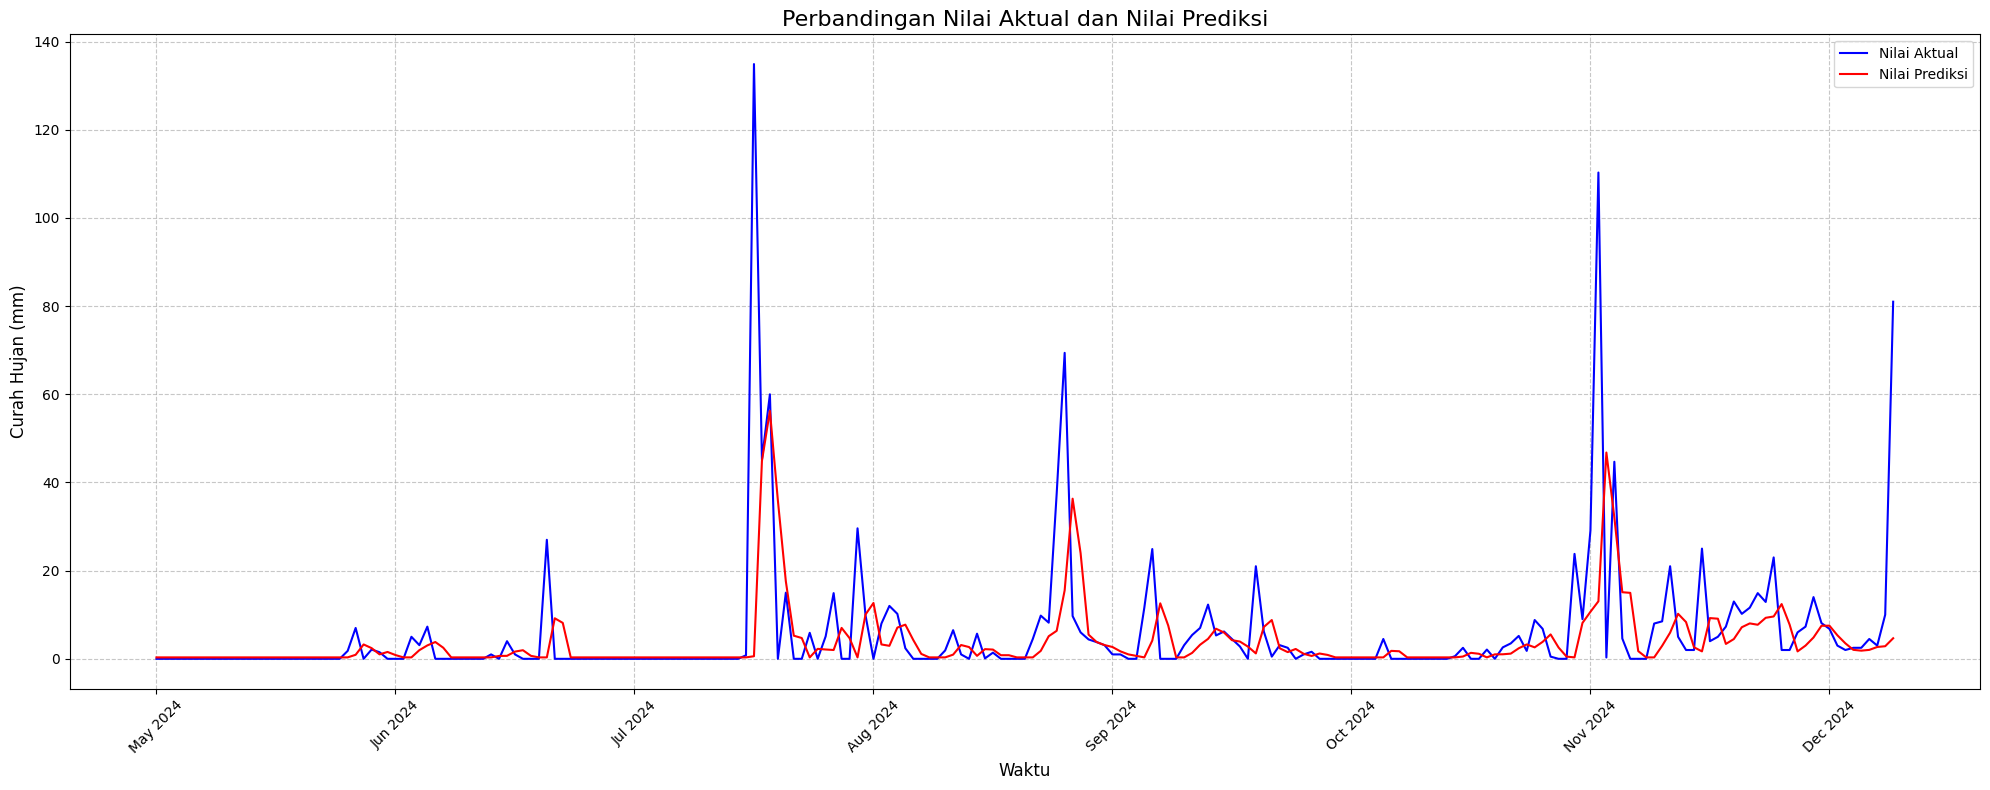

MAE for Best ELM model: 5.442824141149543
MSE for Best ELM model: 223.3795664439287


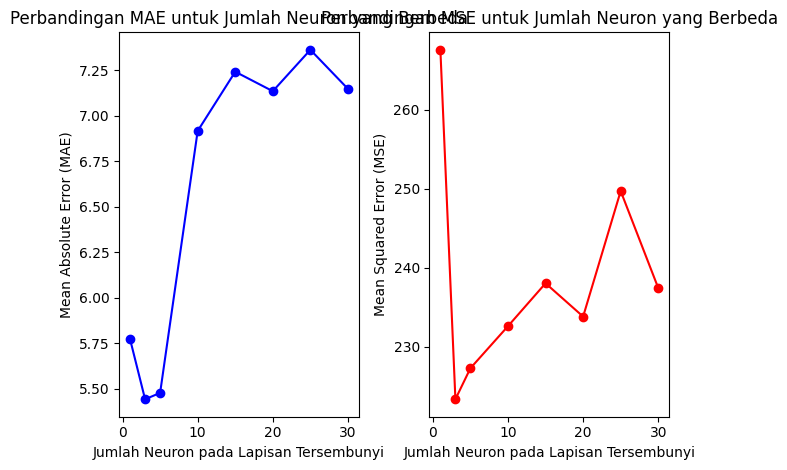

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pickle
import scipy.stats as stats
from scipy.stats import genextreme, genpareto

file_path = "Data Curah Hujan Harian Cleaned.xlsx" 
data = pd.read_excel(file_path, header=0)
data['Curah Hujan'] = pd.to_numeric(data['Curah Hujan'], errors='coerce')
data['Tanggal'] = pd.to_datetime(data['Tanggal'], errors='coerce')

for i in range(1, 3):
    data[f'Lag-{i}'] = data['Curah Hujan'].shift(i)
data.dropna(subset=[f'Lag-{i}' for i in range(1, 3)], inplace=True)

X = data[[f'Lag-{i}' for i in range(1, 3)]].values
y = data['Curah Hujan'].values

train_ratio = 0.8
train_size = int(len(X) * train_ratio)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

class ELM:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.weights = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.biases = np.random.uniform(-1, 1, (1, hidden_size))
        self.output_weights = np.random.uniform(-1, 1, (hidden_size, output_size))

    def relu_activation(self, x):
        return np.maximum(0, x)

    def train(self, X, y):
        H = self.relu_activation(np.dot(X, self.weights) + self.biases)
        H_pseudo_inv = np.linalg.pinv(H)
        self.output_weights = np.dot(H_pseudo_inv, y)

    def predict(self, X):
        H = self.relu_activation(np.dot(X, self.weights) + self.biases)
        predictions = np.dot(H, self.output_weights)
        return np.maximum(predictions, 0)

best_mae = float('inf')
best_mse = float('inf')

best_hidden_size_mae = None
best_hidden_size_mse = None

best_elm_mae = None
best_elm_mse = None

mae_scores_for_hidden_sizes = []
mse_scores_for_hidden_sizes = []

hidden_sizes = [1, 3, 5, 10, 15, 20, 25, 30]

for hidden_size in hidden_sizes:
    elm = ELM(input_size=X_train.shape[1], hidden_size=hidden_size, output_size=1)
    elm.train(X_train, y_train)
    predictions = elm.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    
    mae_scores_for_hidden_sizes.append(mae)
    mse_scores_for_hidden_sizes.append(mse)
    
    if mae < best_mae:
        best_mae = mae
        best_hidden_size_mae = hidden_size
        best_elm_mae = elm

    if mse < best_mse:
        best_mse = mse
        best_hidden_size_mse = hidden_size
        best_elm_mse = elm

    print(f"Jumlah Neuron pada Hidden Layer: {hidden_size}")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")

print(f"Best MAE: {best_mae} untuk Jumlah Neuron: {best_hidden_size_mae}")
print(f"Best MSE: {best_mse} untuk Jumlah Neuron: {best_hidden_size_mse}")

best_predictions = best_elm_mae.predict(X_test)

plt.figure(figsize=(20, 8))
plt.plot(y_test, color='blue', label='Nilai Aktual')
plt.plot(best_predictions, color='red', label='Nilai Prediksi')
plt.title('Perbandingan Nilai Aktual dan Nilai Prediksi', fontsize=16)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
dates = data['Tanggal'].iloc[-len(y_test):]
years_months = dates.dt.strftime('%b %Y')
plt.xticks(ticks=np.arange(0, len(dates), step=30), labels=years_months[::30], rotation=45, fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"MAE for Best ELM model: {best_mae}")
print(f"MSE for Best ELM model: {best_mse}")

plt.subplot(1, 2, 1)
plt.plot(hidden_sizes, mae_scores_for_hidden_sizes, marker='o', color='blue')
plt.xlabel('Jumlah Neuron pada Lapisan Tersembunyi')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Perbandingan MAE untuk Jumlah Neuron yang Berbeda')

plt.subplot(1, 2, 2)
plt.plot(hidden_sizes, mse_scores_for_hidden_sizes, marker='o', color='red')
plt.xlabel('Jumlah Neuron pada Lapisan Tersembunyi')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Perbandingan MSE untuk Jumlah Neuron yang Berbeda')
plt.tight_layout()
plt.show()

In [14]:
with open('best_elm_model_mae.pkl', 'rb') as file:
    best_elm_mae = pickle.load(file)
    
last_two = data['Curah Hujan'].iloc[-2:].values

n_days = 31
predictions = []

lags = last_two.copy()
for _ in range(n_days):
    x_input = lags[::-1].reshape(1, -1)  
    pred = best_elm_mae.predict(x_input)[0]
    pred = max(pred, 0)
    predictions.append(pred)
    lags = np.array([lags[-1], pred])

last_date = data['Tanggal'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_days, freq='D')

df_forecast = pd.DataFrame({
    'Tanggal': future_dates,
    'Prediksi Curah Hujan (mm)': predictions
})

print(df_forecast)


      Tanggal  Prediksi Curah Hujan (mm)
0  2025-01-01                  31.543016
1  2025-01-02                  35.800570
2  2025-01-03                  22.119101
3  2025-01-04                  18.795307
4  2025-01-05                  13.488638
5  2025-01-06                  10.678326
6  2025-01-07                   8.105753
7  2025-01-08                   6.376786
8  2025-01-09                   5.005716
9  2025-01-10                   4.013568
10 2025-01-11                   3.258950
11 2025-01-12                   2.700488
12 2025-01-13                   2.280966
13 2025-01-14                   1.968389
14 2025-01-15                   1.757848
15 2025-01-16                   1.617010
16 2025-01-17                   1.522571
17 2025-01-18                   1.459298
18 2025-01-19                   1.416893
19 2025-01-20                   1.388477
20 2025-01-21                   1.369435
21 2025-01-22                   1.356674
22 2025-01-23                   1.348122
23 2025-01-24   

      Tanggal  Prediksi Curah Hujan (mm)
0  2025-01-01                        1.5
1  2025-01-02                        0.0
2  2025-01-03                        3.5
3  2025-01-04                       14.6
4  2025-01-05                       19.9
5  2025-01-06                        8.5
6  2025-01-07                       19.5
7  2025-01-08                        0.0
8  2025-01-09                       27.3
9  2025-01-10                        0.0
10 2025-01-11                        0.0
11 2025-01-12                       16.3
12 2025-01-13                       19.4
13 2025-01-14                       69.7
14 2025-01-15                        0.6
15 2025-01-16                       24.5
16 2025-01-17                        3.0
17 2025-01-18                        0.0
18 2025-01-19                        0.0
19 2025-01-20                        0.0
20 2025-01-21                        0.0
21 2025-01-22                        4.0
22 2025-01-23                        0.0
23 2025-01-24   

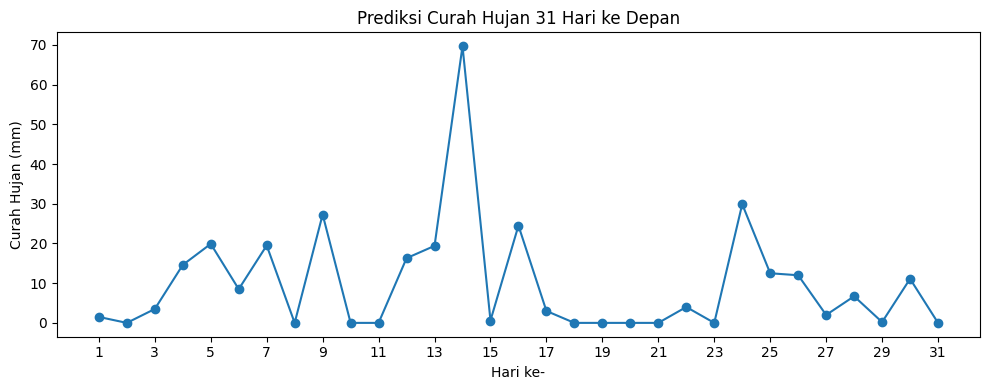

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Masukkan nilai prediksi Anda:
values = [
    1.5, 0.0, 3.5, 14.6, 19.9, 8.5, 19.5, 0.0, 27.3, 0.0,
    0.0, 16.3, 19.4, 69.7, 0.6, 24.5, 3.0, 0.0, 0.0, 0.0,
     0.0, 4.0, 0, 29.9, 12.5, 12,2, 6.7, 0.2, 11.1, 0.0, 
]

# Tentukan tanggal mulai:
start_date = '2025-01-01'
dates = pd.date_range(start=start_date, periods=len(values), freq='D')

# Buat DataFrame:
df_forecast = pd.DataFrame({
    'Tanggal': dates,
    'Prediksi Curah Hujan (mm)': values
})

# Tampilkan hasil di console:
print(df_forecast)

# Simpan ke CSV atau Excel jika perlu:
df_forecast.to_csv('forecast_31_days.csv', index=False)

# Plot dengan indeks sebagai sumbu-x:
plt.figure(figsize=(10, 4))
plt.plot(df_forecast.index + 1, 
         df_forecast['Prediksi Curah Hujan (mm)'], 
         marker='o')
plt.title('Prediksi Curah Hujan 31 Hari ke Depan')
plt.xlabel('Hari ke-')
plt.ylabel('Curah Hujan (mm)')
plt.xticks(ticks=range(1, len(values)+1, 2))  # misal tiap 2 hari
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
from scipy.optimize import minimize

monthly_extremes = np.array([117, 144, 76.5, 32, 32.5, 78, 40.5, 66.5, 40.5, 58.5, 89.6, 126.4,
                            130, 200, 112.5, 45, 37.8, 20, 66, 26, 25.5, 39, 126, 29.5])

def log_likelihood(params, data):
    mu, sigma, xi = params
    n = len(data)
    
    # Validasi parameter
    if sigma <= 0:
        return np.inf
    if np.any(1 + xi * (data - mu) / sigma <= 0):
        return np.inf
    
    # Hitung log-likelihood
    term1 = -n * np.log(sigma)
    term2 = -(1 + 1 / xi) * np.sum(np.log(1 + xi * (data - mu) / sigma))
    term3 = -np.sum((1 + xi * (data - mu) / sigma) ** -(1 / xi))
    
    return -(term1 + term2 + term3)  

initial_guess = [np.mean(monthly_extremes), np.std(monthly_extremes), -0.4731722913830413]

result = minimize(log_likelihood, initial_guess, args=(monthly_extremes,), bounds=[(None, None), (0.01, None), (None, None)])

mu_mle, sigma_mle, xi_mle = result.x
print(f"GEV Parameters (MLE) - Shape (xi): {xi_mle}, Location (mu): {mu_mle}, Scale (sigma): {sigma_mle}")


GEV Parameters (MLE) - Shape (xi): -0.4731722913830413, Location (mu): 73.30416666666666, Scale (sigma): 46.53277947825836


c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


In [2]:
import numpy as np

monthly_extremes = np.array([117, 144, 76.5, 32, 32.5, 78, 40.5, 66.5, 40.5, 58.5, 89.6, 126.4,
                            130, 200, 112.5, 45, 37.8, 20, 66, 26, 25.5, 39, 126, 29.5])

mu = 44.9885312677102 
sigma = 25.517996151905685
xi = -0.4731722913830413

sorted_data = np.sort(monthly_extremes)
n = len(sorted_data)

F_n = np.arange(1, n + 1) / n

t_x = 1 + xi * (sorted_data - mu) / sigma
t_x = np.maximum(t_x, 1e-10)

F_theoretical = np.exp(-(t_x) ** -(1 / xi))

D_n = np.max(np.abs(F_n - F_theoretical))

p_value = 1 - np.exp(-2 * n * D_n**2)

print(f"KS Statistic: {D_n}")
print(f"P-Value: {p_value}")


KS Statistic: 0.2674987785075099
P-Value: 0.9677639095335557


In [6]:
import numpy as np
from scipy.optimize import minimize

monthly_extremes = np.array([117, 144, 76.5, 32, 32.5, 78, 40.5, 66.5, 40.5, 58.5, 89.6, 126.4,
                            130, 200, 112.5, 45, 37.8, 20, 66, 26, 25.5, 39, 126, 29.5])

def gpd_log_likelihood(params, data, threshold):
    sigma, xi = params
    n = len(data)
    
    exceedances = data - threshold
    
    if sigma <= 0:
        return np.inf
    if np.any(1 + xi * exceedances / sigma <= 0):
        return np.inf
    
    term1 = -n * np.log(sigma)
    term2 = -(1 + 1 / xi) * np.sum(np.log(1 + xi * exceedances / sigma))
    
 
    log_likelihood = term1 + term2
    
    return -log_likelihood

threshold = 90
extreme_values = monthly_extremes[monthly_extremes > threshold]

initial_guess = [np.std(extreme_values), 0.1]

result = minimize(gpd_log_likelihood, initial_guess, args=(extreme_values, threshold), bounds=[(0.01, None), (None, None)])

sigma_mle, xi_mle = result.x

print(f"GPD Parameters (MLE) - Shape (xi): {xi_mle}, Scale (sigma): {sigma_mle}")

sigma = 327.2133086508484
xi = -1.6307727049619496

sorted_data = np.sort(monthly_extremes)
n = len(sorted_data)

F_n = np.arange(1, n + 1) / n

t_x = 1 + xi * (sorted_data - threshold) / sigma
t_x = np.maximum(t_x, 1e-10)

F_theoretical = 1-t_x ** -(1 / xi)

D_n = np.max(np.abs(F_n - F_theoretical))

p_value = 1 - np.exp(-2 * n * D_n**2)

print(f"KS Statistic: {D_n}")
print(f"P-Value: {p_value}")


GPD Parameters (MLE) - Shape (xi): -0.7086598425423289, Scale (sigma): 83.42568947152861
KS Statistic: 0.7892150443364742
P-Value: 0.9999999999998963
